# Sinogram Viewer
Loads the sinogram volume produced by `scripts/projections_to_sinograms.py` and visualises individual sinograms.

The HDF5 dataset layout is:
```
sinograms[h, :, :]   →  sinogram at detector row h
  axis-0: height index  (H)
  axis-1: projection / angle index  (N_proj)
  axis-2: detector column  (W)
```

## 1. Import Required Libraries

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## 2. Load the Dataset

In [10]:
H5_PATH = Path("/myhome/data/sdate/shared/compression_paper/file_1_extracted/sinograms.h5")

f = h5py.File(H5_PATH, "r")
ds = f["sinograms"]   # shape (H, N_proj, W), opened lazily — nothing loaded yet

print("Dataset shape :", ds.shape)
print("Dataset dtype :", ds.dtype)
print()
for key, val in f.attrs.items():
    print(f"  {key}: {val}")

Dataset shape : (2160, 1501, 2560)
Dataset dtype : float32

  attenuation: True
  description: Sinogram volume. sinograms[h, :, :] → sinogram at detector row h; axis-0 = height, axis-1 = projection / angle, axis-2 = detector column. Values are attenuation projections: -log((I - dark) / (flat - dark + ε)).
  height: 2160
  num_projections: 1501
  sinogram_shape: (H=2160, N_proj=1501, W=2560)
  source_folder: /mydata/sdate/shared/compression_paper/file_1_extracted
  width: 2560


## 3. Extract the First Sinogram

In [11]:
ROW_IDX = 0   # <-- change this to inspect a different sinogram row

# ds[h] loads only one row from disk: shape (N_proj, W)
sinogram = ds[ROW_IDX][:]

H, N_proj, W = ds.shape
print(f"Sinogram at row h={ROW_IDX}")
print(f"  Shape : {sinogram.shape}  (N_proj={N_proj}, W={W})")
print(f"  dtype : {sinogram.dtype}")
print(f"  min   : {sinogram.min():.2f}")
print(f"  max   : {sinogram.max():.2f}")
print(f"  mean  : {sinogram.mean():.2f}")

Sinogram at row h=0
  Shape : (1501, 2560)  (N_proj=1501, W=2560)
  dtype : float32
  min   : -0.08
  max   : 1.48
  mean  : 0.81


## 4. Visualize the First Sinogram

In [12]:
from ipywidgets import interact, IntSlider
@interact(row=IntSlider(min=0, max=H-1, step=1, value=0))
def show_sinogram_row(row):
    sinogram = ds[row][:]
    plt.figure(figsize=(10, 5))
    plt.imshow(sinogram.T, aspect='auto', cmap='gray')
    plt.title(f"Sinogram at row h={row}")
    plt.xlabel("Projection index")
    plt.ylabel("Detector pixel index")
    plt.colorbar(label="Intensity")
    plt.show()

interactive(children=(IntSlider(value=0, description='row', max=2159), Output()), _dom_classes=('widget-intera…

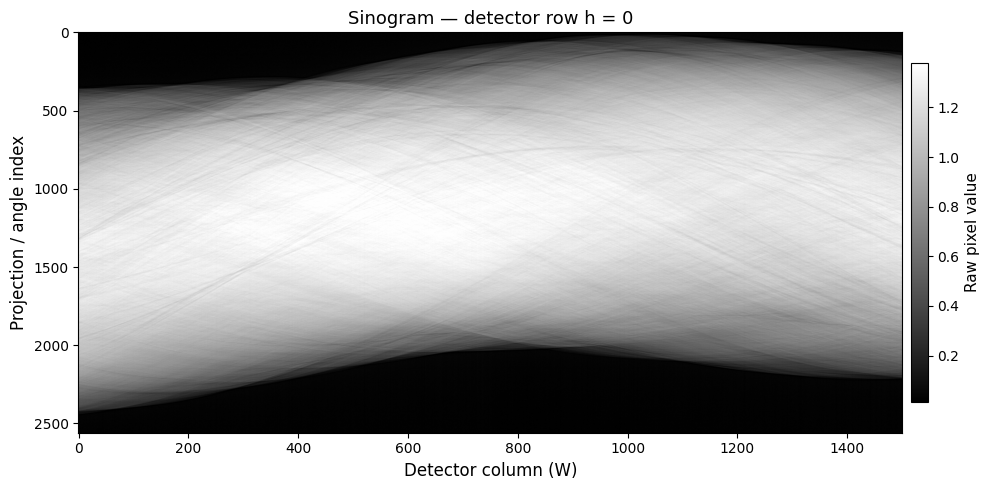

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# clip to [1%, 99%] percentile to suppress hot/dead pixels
vmin, vmax = np.percentile(sinogram, [1, 99])

im = ax.imshow(
    sinogram.T,
    aspect="auto",
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    origin="upper",
)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Raw pixel value", fontsize=11)

ax.set_xlabel("Detector column (W)", fontsize=12)
ax.set_ylabel("Projection / angle index", fontsize=12)
ax.set_title(f"Sinogram — detector row h = {ROW_IDX}", fontsize=13)

plt.tight_layout()
plt.show()

## 5. FBP Reconstruction

Reconstruct the slice using **Filtered Back-Projection** (ramp filter).  
Projections are assumed to be evenly spaced over **[0°, 180°)**.

In [14]:
from skimage.transform import iradon

# Angles evenly spaced from 0° to 180° (not including 180°)
theta = np.linspace(0.0, 180.0, N_proj, endpoint=False)

# iradon expects shape (W, N_proj): detector pixels × projections
# sinogram is (N_proj, W), so transpose
reconstruction = iradon(sinogram.T, theta=theta, filter_name="ramp")

print(f"Angles          : {theta[0]:.2f}° → {theta[-1]:.2f}°  ({N_proj} steps)")
print(f"Reconstruction shape : {reconstruction.shape}")
print(f"  min  : {reconstruction.min():.4f}")
print(f"  max  : {reconstruction.max():.4f}")
print(f"  mean : {reconstruction.mean():.4f}")

Angles          : 0.00° → 179.88°  (1501 steps)
Reconstruction shape : (2560, 2560)
  min  : -0.0024
  max  : 0.0027
  mean : 0.0003


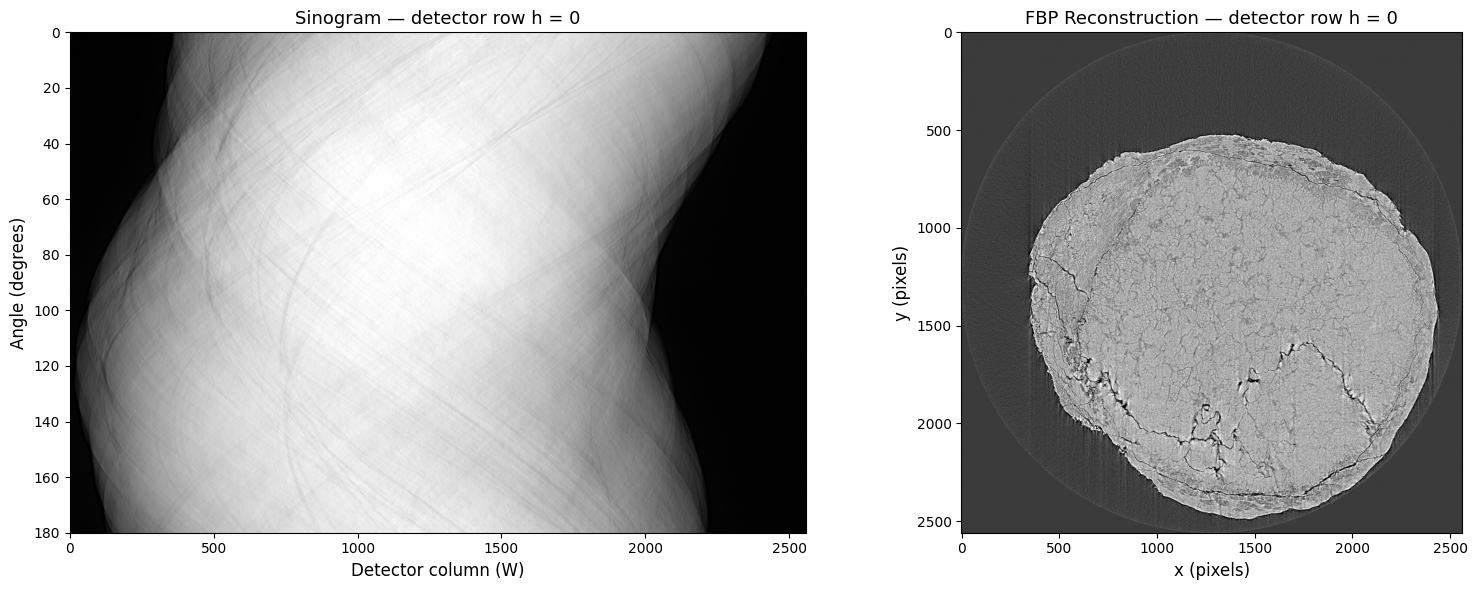

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Sinogram ---
vmin_s, vmax_s = np.percentile(sinogram, [1, 99])
axes[0].imshow(
    sinogram,
    aspect="auto",
    cmap="gray",
    vmin=vmin_s,
    vmax=vmax_s,
    origin="upper",
    extent=[0, W, 180, 0],
)
axes[0].set_xlabel("Detector column (W)", fontsize=12)
axes[0].set_ylabel("Angle (degrees)", fontsize=12)
axes[0].set_title(f"Sinogram — detector row h = {ROW_IDX}", fontsize=13)

# --- FBP Reconstruction ---
vmin_r, vmax_r = np.percentile(reconstruction, [1, 99])
axes[1].imshow(
    reconstruction,
    cmap="gray",
    vmin=vmin_r,
    vmax=vmax_r,
    origin="upper",
)
axes[1].set_xlabel("x (pixels)", fontsize=12)
axes[1].set_ylabel("y (pixels)", fontsize=12)
axes[1].set_title(f"FBP Reconstruction — detector row h = {ROW_IDX}", fontsize=13)

plt.tight_layout()
plt.show()

## 6. Stream Compression with HEVC

Compress all sinograms in the dataset using the HEVC gray10 streamer.
Each sinogram is treated as a frame in the compressed video stream.

In [16]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [ ]:
from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams
import tempfile
import torch

# Configuration for compression
quality = 100  # HEVC quality (0-100, higher is better)
n_sinograms_to_compress = H  # Compress all sinograms by default

print(f"🎥 HEVC Stream Compression")
print(f"   Dataset shape: {ds.shape}")
print(f"   Compressing {n_sinograms_to_compress} sinograms...")
print(f"   Quality setting: {quality}")

🎥 HEVC Stream Compression
   Dataset shape: (2160, 1501, 2560)
   Compressing 2160 sinograms...
   Quality setting: 100


In [ ]:
# Create temporary directory for HEVC output
hvec_temp_dir = Path(tempfile.mkdtemp())
hvec_output = hvec_temp_dir / "sinograms_compressed.mov"

print(f"🎬 Starting HEVC compression...")
print(f"   Output directory: {hvec_temp_dir}")

# Create encoder parameters
# Force software encoding since hardware encoder may not be available
params = EncoderParams(
    fps=24,
    cq_hw=quality,  # Hardware quality (not used in software mode)
    crf_sw=min(51, 51 - int(min(quality, 100) * 51 / 100)),  # Software quality - lower CRF is better (0-51)
    preset_sw="medium",  # Encoding speed preset: ultrafast, superfast, veryfast, faster, fast, medium, slow, slower, veryslow
    force_software=True  # Force software encoding (libx265)
)

# Create HEVC streamer
streamer = HevcGray10Streamer(
    base_path=hvec_temp_dir,
    segment_prefix="sinogram",
    params=params
)

print("Streaming sinograms directly to encoder...")
# Stream sinograms directly: load, normalize, and encode one at a time
with streamer.start_segment():
    for h in range(n_sinograms_to_compress):
        # Load sinogram at height h: shape (N_proj, W)
        sino = ds[h][:]
        
        # Convert to torch tensor
        sino_tensor = torch.tensor(sino, dtype=torch.float32)
        
        # Normalize to [0, 1] range
        sino_min = sino_tensor.min()
        sino_max = sino_tensor.max()
        if sino_max > sino_min:
            sino_normalized = (sino_tensor - sino_min) / (sino_max - sino_min)
        else:
            sino_normalized = torch.zeros_like(sino_tensor)
        
        # Encode directly (no need to store in memory)
        streamer.append_frame(sino_normalized)
        
        if (h + 1) % 100 == 0:
            print(f"   Processed {h + 1}/{n_sinograms_to_compress} sinograms")

print(f"✅ Encoding complete!")
print(f"   Using: {'Hardware' if streamer._using_hardware else 'Software'} encoder")

Loading and normalizing sinograms...
   Loaded 100/2160 sinograms
   Loaded 200/2160 sinograms
   Loaded 300/2160 sinograms
   Loaded 400/2160 sinograms
   Loaded 500/2160 sinograms
   Loaded 600/2160 sinograms
   Loaded 700/2160 sinograms
   Loaded 800/2160 sinograms
   Loaded 900/2160 sinograms
   Loaded 1000/2160 sinograms
   Loaded 1100/2160 sinograms
   Loaded 1200/2160 sinograms
   Loaded 1300/2160 sinograms
   Loaded 1400/2160 sinograms
   Loaded 1500/2160 sinograms
   Loaded 1600/2160 sinograms
   Loaded 1700/2160 sinograms
   Loaded 1800/2160 sinograms
   Loaded 1900/2160 sinograms
   Loaded 2000/2160 sinograms
   Loaded 2100/2160 sinograms
✅ Loaded 2160 sinograms as frames
   Frame shape: torch.Size([1501, 2560])


In [ ]:
# Get compression statistics
hvec_file = streamer.segments[0]
hvec_size = hvec_file.stat().st_size

# Calculate original data size
# Each sinogram has shape (N_proj, W) and dtype float32 (4 bytes per element)
bytes_per_sinogram = N_proj * W * 4  # 4 bytes for float32
total_original_size = bytes_per_sinogram * n_sinograms_to_compress

# Compression ratio
compression_ratio = total_original_size / hvec_size

print(f"\n📊 Compression Statistics:")
print(f"   Output file: {hvec_file.name}")
print(f"   Sinograms compressed: {n_sinograms_to_compress} (shape: {N_proj} × {W})")
print(f"   Original size: {total_original_size:,} bytes ({total_original_size / (1024**2):.2f} MB)")
print(f"   Compressed size: {hvec_size:,} bytes ({hvec_size / (1024**2):.2f} MB)")
print(f"   Compression ratio: {compression_ratio:.2f}x")
print(f"   Space saved: {(1 - hvec_size/total_original_size) * 100:.1f}%")
print(f"   Bits per pixel: {(hvec_size * 8) / (n_sinograms_to_compress * N_proj * W):.3f}")


📊 Compression Statistics:
   Output file: sinogram_0000.mov
   Original size: 3,838,060,800 bytes (3660.26 MB)
   Compressed size: 684,789,788 bytes (653.07 MB)
   Compression ratio: 5.60x
   Space saved: 82.2%
   Bits per pixel: 5.709
